<a href="https://colab.research.google.com/github/matti410/Trading-System-Creator_V4/blob/main/Trading_Grid_Search_v4_backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ricerca di Trading System

Serve a **scoprire se un segnale di ingresso ha un vantaggio reale**, separando entry, uscita e "quando sto fermo" — cercarli insieme confonde quale dei tre sta davvero funzionando.

Si legge dall'alto in basso, senza celle facoltative: ogni sezione usa il risultato di quella prima.

**Ordine:** la Sessione 1 misura il segnale puro (nessun capitale, nessuna posizione). La Sessione 2 sceglie come uscirne e diventa un sistema vero, con trade e costi.

In [1]:
!pip install -q TA-Lib==0.8.1 backtesting==0.6.6   # versioni bloccate: cambiarle solo insieme al notebook di collaudo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 7.9 MB/s eta 0:00:00


### Sezione 0 · Preparazione

Clona la repo e prepara l'ambiente. Va eseguita una volta sola a inizio sessione Colab.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
from pathlib import Path
from google.colab import userdata
import shutil
# Salva il token una volta in Colab: icona chiave a sinistra → "Secrets" → aggiungi GITHUB_TOKEN
# Assicurati che il nome del secret sia 'GITHUB_TOKEN' (o quello che preferisci) e non il token stesso.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

REPO_DIR = Path('/content/Trading-System-Creator_V4')
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)  # ripulisce il tentativo fallito precedente

!git clone https://{GITHUB_TOKEN}@github.com/matti410/Trading-System-Creator_V4.git

%cd Trading-System-Creator_V4

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Cloning into 'Trading-System-Creator_V4'...
remote: Enumerating objects: 298, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 298 (delta 75), reused 0 (delta 0), pack-reused 159 (from 1)
Receiving objects: 100% (298/298), 9.57 MiB | 3.75 MiB/s, done.
Resolving deltas: 100% (154/154), done.
/content/Trading-System-Creator_V4


In [2]:
import datetime as dt
from dateutil.relativedelta import relativedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import talib as ta

import entry_long, entry_short
import exit_long, exit_short
import engine as eng
from engine.vwap_ops import vwap_anchored_daily
import engine.event_study
import engine.splitting
from engine.exit_search_bt import run_exit_search_bt
import filter_conditions, vwap_regime_filter_conditions
from engine.filter_search_bt import run_filter_search_bt
from engine.due_meta import due_meta
from engine.equity_plot import plot_equity
from engine.costi import (parametri_backtest, verifica_da_storico_deals,
                          deriva_costo_nel_tempo, spread_corrente)
from engine.giudizio import scheda_strategia, soglia_rumore
from engine.broker_tz_diagnostic import to_utc_index
from engine.quarantena import verifica_indice_utc, quarantena
from engine.sessioni import in_sessione, barre_da_apertura, elenco_sessioni
from entry_metro import registra_trigger_metro, NOMI_METRO
from engine.indicatori import aggiungi_indicatori
from engine.confidenza import (esiti_trade, confidenza_rolling,
                               registra_filtro_confidenza,
                               report_calibrazione, plot_oos_confidenza)

/usr/local/lib/python3.13/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


## Sezione 1 · I dati

Scarica le candele da MetaTrader 5.

**Parametri che puoi cambiare:** strumento, timeframe, periodo storico.

In [3]:
symbol    = "BTCUSD"
timeframe = 'M15'
FREQ      = "15min"      # come pandas scrive il timeframe: "15min", "h", "D"

df = pd.read_csv(f'{symbol}_M15.csv', index_col='Date')
df = to_utc_index(df, "A_US_DST (NY+7h)", on_dst_gap="drop")

print(f"{symbol} {timeframe} — {len(df):,} barre  ·  da {df.index[0]}  a  {df.index[-1]}")
df.tail(3)

to_utc_index: scartate 30 barre su 221638 (0.0135%) nei cambi d'ora.
  novembre = ora ripetuta, marzo = ora inesistente
    2021-03: 2
    2021-11: 4
    2022-03: 1
    2022-11: 4
    2023-03: 3
    2023-11: 4
    2024-03: 2
    2024-11: 4
    2025-03: 1
    2025-11: 4
    2026-03: 1
BTCUSD M15 — 221,608 barre  ·  da 2020-01-01 22:00:00+00:00  a  2026-09-19 06:00:00+00:00


,Open,High,Low,Close,Volume,spread
Date,,,,,,
2026-09-19 05:30:00+00:00,81036.52,81106.98,80992.66,81007.07,5049,500
2026-09-19 05:45:00+00:00,81007.08,81064.38,80958.77,81014.22,6207,500
2026-09-19 06:00:00+00:00,81013.43,81055.24,80968.52,80978.59,5284,500


### Strato 1-2 — quarantena e sessioni

`verifica_indice_utc` si ferma se l'indice non è UTC vero (difesa contro
l'etichetta fantasma). `quarantena` marca le barre non affidabili: la
finestra del rollover 16:45-18:00 NY, dove i prezzi bid sono deformati
dall'allargamento dello spread, e la prima barra dopo ogni interruzione.

Attese su EURUSD M15: ~5,2% di barre in quarantena. Se la percentuale
è molto diversa, fermati e controlla l'indice prima di proseguire.

In [4]:
verifica_indice_utc(df)
q = quarantena(df)

display(elenco_sessioni())

[verifica_indice_utc] OK — 100.0% delle 54 riaperture cade domenica 17:00 New York. Barre da 0 days 00:15:00.
[quarantena] 221608 barre esaminate
    rollover               10653  (4.81%)
    dopo_interruzione        228  (0.10%)
    totale                 10761  (4.86%)
    finestra rollover: 16:45-18:00 ora di New York


,fuso,apertura,chiusura,usabile come
sessione,,,,
ROLLOVER,America/New_York,17:00,— (istante),evento
TOKYO,Asia/Tokyo,09:00,18:00,evento + filtro
LONDRA,Europe/London,08:00,17:00,evento + filtro
NEW_YORK,America/New_York,08:00,17:00,evento + filtro
NYSE,America/New_York,09:30,16:00,evento + filtro
FIX_LONDRA,Europe/London,16:00,— (istante),evento


In [5]:
costi = parametri_backtest(symbol, bars=df, valuta_conto="USD", percentile=75.0, usa_mt5 = False, spread_pips = 0.1,)
costi   # -> {'spread': ..., 'commission': ...}

BTCUSD  [forex]  conto in USD
   prezzo mediano   : 46,581.5   nozionale: 4,658,145,500 USD
   spread           :  0.021 bp   <- listino (0.1 pips) — senza MT5
   commissione      :  0.000 bp   <- 7.00 USD round-turn per lotto
   COSTO ROUND-TURN :  0.021 bp
   -> spread=2.147e-06   commission=7.514e-10   (commission e' PER LATO: round-turn / 2)
   -> in pips: spread 0.100 + commissione 0.000 = 0.100 pips round-turn


{'spread': 2.1467770811366884e-06, 'commission': 7.513719783978409e-10}

### Entry-metro — il righello temporale

Cinque ingressi che entrano all'apertura di una sessione e basta, senza
nessuna condizione di prezzo. **Non sono strategie: sono un metro.**

| Metro | Apertura |
|---|---|
| `M_TOKYO` | 09:00 Asia/Tokyo |
| `M_LONDRA` | 08:00 Europe/London |
| `M_NEW_YORK` | 08:00 America/New_York |
| `M_NYSE` | 09:30 America/New_York |
| `M_FIX_LONDRA` | 16:00 Europe/London |

Servono a rispondere a una domanda sola: **il mio pattern di prezzo fa
meglio del semplice entrare a quell'ora?** Un pattern che non batte il
proprio metro non sta aggiungendo informazione di prezzo: sta scegliendo
l'orologio.

#### Come si legge il segno

La curva è `(Close[i+k] / Open[i+1] - 1) × direction`, in percentuale.
Con `direction = +1` (long):

- **valore positivo** → da quell'ora in avanti il prezzo mediamente **sale**
- **valore negativo** → mediamente **scende** (quindi sarebbe uno short)

Due avvertenze che cambiano la lettura:

1. **L'ingresso è alla barra dopo.** Il trigger scatta sulla barra di
   apertura, ma si entra all'apertura della barra successiva — la regola
   anti-lookahead del framework, uguale per tutte le entry. `M_LONDRA`
   misura quindi il movimento dalle **08:15** di Londra, non dalle 08:00.
2. **Conta lo scostamento dalla linea nera del mercato, non l'altezza.**
   Su un asset con deriva la curva grezza sale da sola: guarda
   `vs_mercato_pct`.

#### Cosa NON sono

Se una metro esce con `volte_incertezza` alto, **non è un edge**: è deriva
intraday dell'asset. Le ampiezze sono di 1-2 pips, dentro il rumore dei
costi.

E soprattutto: **non vanno contate fra le prove.** Quando passi `k` a
`soglia_rumore`, passa il numero di entry *vere*, non il numero di righe
della tabella. `NOMI_METRO` serve a escluderle anche dalla ricerca delle
uscite.

[registra_trigger_metro] 5 metro registrate (0 gia' presenti).
    Sono un RIFERIMENTO, non candidati: escludile dal conteggio dei test multipli (k) e dalla ricerca delle uscite. Usa NOMI_METRO.
pip = 1 unita' di prezzo  (prezzo medio 51,669.49)
  barra   6/48
  barra  12/48
  barra  18/48
  barra  24/48
  barra  30/48
  barra  36/48
  barra  42/48
  barra  48/48

5 entry · orizzonte 48 barre · 8,748 trigger misurati
soglia di rumore per 5 entry × picco su 48 barre (famiglia 5%): |volte_incertezza| > 3.33  —  entry oltre: 0. Conta solo le prove di questa chiamata, e' un pavimento


,candidato,direction,trades,barra_picco,picco_pips,picco_pct,incertezza_pct,volte_incertezza,a_fine_pct,vs_mercato_pct,barra_picco_netto,picco_in_coda,oltre_rumore
0,M_FIX_LONDRA,1,1750,31,67.579100,0.135297,0.050541,2.676987,0.085249,0.083678,31,False,False
1,M_NEW_YORK,1,1750,43,80.501900,0.161129,0.062152,2.592485,0.150508,0.090096,43,True,False
2,M_NYSE,1,1749,37,70.975375,0.142082,0.057739,2.460768,0.114044,0.080785,37,True,False
3,M_LONDRA,1,1749,48,50.608727,0.101350,0.060608,1.672234,0.101350,0.022163,25,False,False
4,M_TOKYO,1,1750,18,-26.102533,-0.052268,0.033017,-1.583073,0.041908,-0.082797,18,False,False


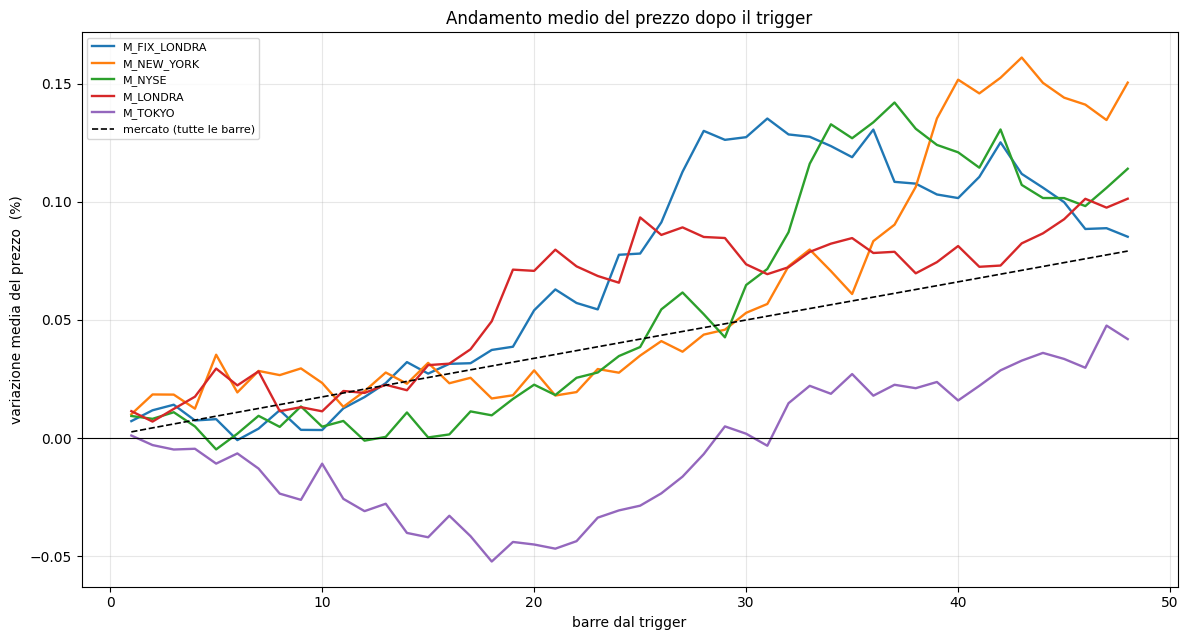

In [6]:
registra_trigger_metro()

ev_metro = engine.event_study.run_event_study(df, entry_names=list(NOMI_METRO), horizon=48)
display(ev_metro.sintesi)
ev_metro.plot()

## Sezione 2 · Gli indicatori

Le condizioni di ingresso (`entry_long.py`, `entry_short.py`) non calcolano niente da sole: leggono colonne già pronte in questa tabella. Qui le costruiamo.

| Colonna | Cos'è | Chi la usa |
|---|---|---|
| `rsi` | oscillatore 0-100: sotto 30 il prezzo è "sceso troppo", sopra 70 "salito troppo" | l'entry mean reversion |
| `ema20`, `ema50` | medie mobili veloce e lenta | l'entry di controllo |
| `zlema50` | media mobile a ritardo ridotto | l'entry di trend |
| `atr`, `realized_vol` | quanto si muove il prezzo di solito | dimensionamento futuro |
| `vwap` | prezzo medio della giornata pesato per volume | i filtri di contesto |

Sulla **zero-lag EMA**: una media normale è sempre in ritardo; la ZLEMA lo compensa proiettando in avanti il prezzo, ma esagera i movimenti e genera più falsi attraversamenti — su M15 va bene (più campioni), ma è dove i costi di transazione pesano di più.

In [7]:
df = aggiungi_indicatori(df)
print(f"{len(df):,} barre pronte, {df.shape[1]} colonne")
print(f"adx  — min {df['adx'].min():.1f}  mediana {df['adx'].median():.1f}  max {df['adx'].max():.1f}")
print(f"atr  — mediana {df['atr'].median():.6f}  ({df['atr'].median()/df['Close'].median()*100:.3f}% del prezzo)")
df.tail(3)

221,512 barre pronte, 17 colonne
adx  — min 4.4  mediana 23.7  max 79.9
atr  — mediana 175.893450  (0.377% del prezzo)


,Open,High,Low,Close,Volume,spread,rsi,macd,macd_signal,macd_hist,ema20,ema50,zlema50,atr,realized_vol,adx,vwap
Date,,,,,,,,,,,,,,,,,
2026-09-19 05:30:00+00:00,81036.52,81106.98,80992.66,81007.07,5049,500,46.491185,-3.420676,39.045977,-42.466653,81103.800713,80802.507362,81357.760671,172.037068,0.002401,23.173832,81214.643866
2026-09-19 05:45:00+00:00,81007.08,81064.38,80958.77,81014.22,6207,500,46.851448,-8.669793,29.502823,-38.172616,81095.269216,80810.809819,81349.633585,167.292277,0.002399,21.853474,81207.892691
2026-09-19 06:00:00+00:00,81013.43,81055.24,80968.52,80978.59,5284,500,45.217657,-15.525827,20.497093,-36.022920,81084.156910,80817.389434,81335.821288,161.537115,0.002400,20.627428,81202.168241


## Sezione 3 · Dividere i dati in due

Questa è la regola più importante del notebook, e l'unica che non si può violare.

- **In-Sample (80%)** — la parte su cui si cerca, si prova, si sbaglia quante volte si vuole
- **Out-of-Sample (20%)** — la parte che **non si guarda fino alla fine**

Perché conta: su mille combinazioni provate, qualcuna sembrerà eccellente per puro caso — è garantito, anche su dati casuali. L'unico modo per accorgersene è tenere da parte dati che nessuna combinazione ha mai visto.

Se la guardi, cambi qualcosa e riguardi, l'Out-of-Sample non esiste più: è diventata parte della ricerca. **Si apre una volta sola, a ricerca in-sample conclusa** (passo 6 di `ROADMAP_RICERCA.md`).

In [8]:
IS_RATIO = 0.8
df_is, df_oos = eng.splitting.split_is_oos(df, is_ratio=IS_RATIO)
eng.splitting.describe_split(df_is, df_oos)

,n_barre,quota,dal,al
In-Sample,177209,0.799997,2020-01-02 22:00:00+00:00,2025-06-11 05:30:00+00:00
Out-of-Sample,44303,0.200003,2025-06-11 05:45:00+00:00,2026-09-19 06:00:00+00:00
Totale,221512,1.000000,2020-01-02 22:00:00+00:00,2026-09-19 06:00:00+00:00


## Sezione 4 · Features Engineering

Registra tutti i trigger di ingresso ed uscita nel registro condiviso — va fatto prima di qualunque uso di `event_study` o `exit_search_bt`, che leggono le entry da lì.

In [9]:
entry_long.registra_trigger_long()
entry_short.registra_trigger_short()

exit_long.registra_exit_long()
exit_short.registra_exit_short()

filter_conditions.registra_filtri()
vwap_regime_filter_conditions.registra_filtri_vwap()

[registra_trigger_long] 28 entry long registrate (0 gia' presenti).
[registra_trigger_short] 28 entry short registrate (0 gia' presenti).
[registra_exit_long] 4 exit long registrate (0 gia' presenti).
[registra_exit_short] 4 exit short registrate (0 gia' presenti).
[registra_filtri] 29 filtri registrati (0 gia' presenti).
[registra_filtri_vwap] 5 filtri registrati (0 gia' presenti).


## SESSIONE 1 · L'andamento del prezzo dopo il trigger

Per ogni condizione: tutte le barre in cui è vera, e dove va il prezzo dopo, fino all'orizzonte `H`. Si entra all'apertura della barra successiva al segnale (mai sullo stesso Close che l'ha generato). La curva è sempre "a favore del trade": per una condizione short, sale quando il prezzo scende.

`H` è una scelta, non una griglia: si calcola una volta sola e tutti gli orizzonti più corti si leggono sulla stessa curva.

**Nessuna occorrenza viene scartata**, nemmeno quelle scattate mentre si era già dentro un trade. Ma due trigger vicini vivono le stesse candele, quindi **non contano come due prove indipendenti**: l'incertezza ne tiene conto (dal 24/9).

## 1.1 · Le curve a confronto

Ogni linea è una condizione, asse orizzontale le barre dal trigger, verticale la variazione media in percentuale. **La linea nera tratteggiata è il mercato** (nessuna condizione): il metro di paragone — sopra di lei la curva aggiunge qualcosa, appiccicata a lei non dice niente.

Guarda la **forma**: sale e prosegue = il movimento continua; sale e si appiattisce = il vantaggio ha una scadenza (è lì l'orizzonte del trade); sale e ridiscende = quello che guadagnavi lo restituisci.

In [10]:
H = 25
MIN_TRADES = 200

pip = 1 unita' di prezzo  (prezzo medio 42,674.26)
4 entry scartate sotto min_trades=200
  barra   3/25
  barra   6/25
  barra   9/25
  barra  12/25
  barra  15/25
  barra  18/25
  barra  21/25
  barra  24/25
  barra  25/25

52 entry · orizzonte 25 barre · 230,582 trigger misurati
soglia di rumore per 52 entry × picco su 25 barre (famiglia 5%): |volte_incertezza| > 3.92  —  entry oltre: 1. Conta solo le prove di questa chiamata, e' un pavimento


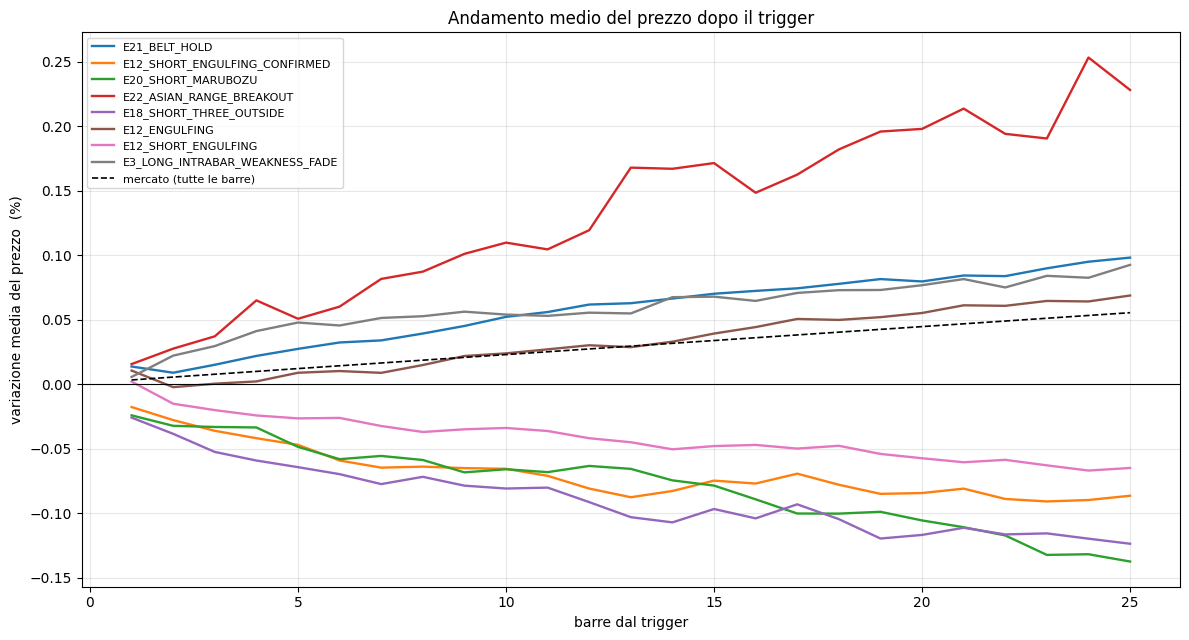

In [11]:
# solo le entry vere: le metro sono un righello, non candidate
entry_candidate = [n for n in eng.registry.list_entries() if n not in NOMI_METRO]
ev = eng.event_study.run_event_study(df_is, entry_names=entry_candidate, horizon=H, min_trades=MIN_TRADES)
ev.plot()
#ev.plot_singola("E7_BIG_TAIL_BARS", pips=True)

## 1.2 · La sintesi
| colonna | cosa dice |
|---|---|
| `trades` | quante volte la condizione è scattata |
| `barra_picco` / `barra_picco_netto` | dove la curva è più estrema, e dove si stacca di più dal mercato (usato da `diagnosi()`) |
| `picco_pct` / `picco_pips` | il valore a quel picco — **può essere negativo**: non è un errore, è un trade che perde |
| `incertezza_pct` | quanto balla la media a quel punto. Tiene conto dei trigger vicini: per le condizioni che scattano spesso è più larga |
| `volte_incertezza` | picco diviso incertezza |
| `oltre_rumore` | **la colonna da guardare per prima**: `True` se `volte_incertezza` supera la soglia stampata sotto il grafico |
| `a_fine_pct` | dove sta il prezzo a fine orizzonte: più basso del picco = il movimento è rientrato |
| `vs_mercato_pct` | quanto il trigger si stacca dal movimento che il mercato fa comunque — vicino a zero = è il respiro dell'asset, non il segnale |
| `picco_in_coda` | `True` = il picco netto cade nell'ultimo quarto della finestra, segno di deriva casuale |

**La soglia di rumore.** Provando 52 condizioni, la prima della classifica sembra buona anche su dati casuali, e in più per ognuna si sceglie la barra migliore dell'orizzonte. La riga sotto il grafico (`soglia di rumore per … entry × picco su … barre`) dice oltre quale `|volte_incertezza|` il risultato non è più spiegabile dal caso. Conta solo le prove di *questa* chiamata: è un pavimento, non un tetto.

La tabella è ordinata per ampiezza, non per solidità: guarda sempre `oltre_rumore`, `trades` e `picco_in_coda` prima di scegliere.

In [12]:
ev.sintesi.round(4).sort_values('picco_pips', ascending=False).head(6)

,candidato,direction,trades,barra_picco,picco_pips,picco_pct,incertezza_pct,volte_incertezza,a_fine_pct,vs_mercato_pct,barra_picco_netto,picco_in_coda,oltre_rumore
3,E22_ASIAN_RANGE_BREAKOUT,1,817,24,109.6637,0.2534,0.0678,3.7385,0.2283,0.2000,24,True,False
21,E14_HARAMI_CROSS,1,1715,24,47.0094,0.1109,0.0445,2.4909,0.0885,0.0575,24,True,False
29,E11_INVERTED_HAMMER,1,930,24,42.7212,0.0961,0.0537,1.7890,0.0934,0.0427,24,True,False
15,E1_RSI_CROSS_OVERSOLD,1,2181,9,41.7917,0.0978,0.0351,2.7863,0.0947,0.0769,7,False,False
8,E20_MARUBOZU,1,4160,25,41.5332,0.0970,0.0300,3.2279,0.0970,0.0414,25,True,False
0,E21_BELT_HOLD,1,13244,25,41.2872,0.0983,0.0208,4.7321,0.0983,0.0427,25,True,True


### LONG side

In [13]:
ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
3,E22_ASIAN_RANGE_BREAKOUT,109.663738,0.253393,3.738491,False
21,E14_HARAMI_CROSS,47.009386,0.110905,2.490884,False
29,E11_INVERTED_HAMMER,42.721224,0.096097,1.789038,False
15,E1_RSI_CROSS_OVERSOLD,41.791726,0.097784,2.786325,False
8,E20_MARUBOZU,41.533242,0.096963,3.227877,False
0,E21_BELT_HOLD,41.287210,0.098266,4.732077,True


In [15]:
LONG_condition_scelta = "E22_ASIAN_RANGE_BREAKOUT"

### SHORT side

In [14]:
ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
34,E10_SHORT_HANGING_MAN,8.525881,0.020330,1.579195,False
50,E4_SHORT_EMA_CROSS_DOWN,-12.699986,-0.029486,-0.723544,False
30,E13_SHORT_HARAMI,-16.824015,-0.040390,-1.723886,False
38,E13_SHORT_HARAMI_CONFIRMED,-18.513915,-0.045108,-1.444962,False
36,E9_SHORT_CLOSING_PATTERN_ONLY_II,-19.526661,-0.045737,-1.496187,False
48,E11_SHORT_SHOOTING_STAR,-22.288349,-0.050242,-0.973109,False


In [16]:
SHORT_condition_scelta = None

In [17]:
ev.diagnosi()

orizzonte impostato          : 25 barre
picchi (netti) nell'ultimo quarto: 56% (29/52, oltre la barra 19)
|picco| / incertezza, mediana: 1.92
|picco| / incertezza, massimo: 4.73
soglia di rumore (52 entry × picco su 25 barre): 3.92  —  entry oltre: 1

I picchi si ammassano in fondo alla finestra: e' il
comportamento di una deriva casuale, non di un segnale.
Prova a rileggere con horizon=6
e guarda se la forma delle curve cambia.


# SESSIONE 2 · Le condizioni di uscita

Fin qui abbiamo **misurato** un segnale: nessun capitale, nessuna posizione, nessun costo. Da adesso costruiamo un **sistema**: si sceglie un ingresso e si cerca il modo di uscirne.

## 2.1 · Come vengono calcolati stop e target

Nessuna soglia scritta a mano: uno stop dello 0.15% è enorme su EURUSD e minuscolo su BTCUSD. Per ogni barra si misura quanto sarebbe andato in rosso e in verde un trade lì aperto e tenuto `n` barre; lo stop del trade che apri ora è il **percentile richiesto di quelle escursioni sulle ultime 500 occorrenze concluse** — si allarga da solo su un asset volatile, si stringe quando il mercato si calma. Il valore si fissa all'apertura e non cambia più.

> **Perché "concluse" e non "partite".** L'escursione di un trade aperto alla barra `i` si conosce solo alla `i+n`. Usare le ultime 500 partite userebbe prezzi futuri per uno stop deciso oggi — la finestra è quindi spostata indietro di `n` barre.


## 2.2 · Backtest con i trigger selezionati

Una riga per combinazione. `combinazione` si legge `L=<entry long> · S=<entry short>`
(`—` dove quel lato non ha ingresso). Sotto `min_trades` le righe spariscono: se una
combinazione attesa non c'è, controlla prima lì.

| colonna | cosa guardi |
|---|---|
| `avg_trade_netto` | **il numero che conta**: pips medi per trade al netto delle commissioni. Sopra zero o non se ne parla |
| `t_stat` | quanto `avg_trade_netto` si distingue da zero, rispetto a quanto ballano i trade |
| `oltre_rumore` | `True` se `t_stat` supera la soglia stampata sopra la tabella |
| `avg_trade` | lo stesso, lordo — serve solo a vedere quanto si mangiano i costi |
| `trades` | sotto il centinaio, qualunque numero è rumore |
| `sharpe`, `max_dd_pct`, `win_rate_pct`, `profit_factor` | contorno |

**La soglia di rumore.** La riga sopra la tabella (`soglia di rumore per … righe`) dice oltre quale `|t_stat|` la riga migliore non è più spiegabile dal caso, contando le righe di *questa* chiamata. È un pavimento, non un tetto.

**Cosa fai dopo:** scegli la combinazione con `avg_trade_netto` più alto e abbastanza
trade, e congelala. In una chiamata l'uscita è identica per tutte le righe: la tabella
dice *quale entry rende di più con QUESTA uscita*, non quale uscita è la migliore.
Per confrontare uscite diverse rilanci con altri valori.

La tabella è ordinata per `sharpe`, non per `avg_trade_netto`: leggila per colonna, non per posizione.

**TEST 1**

Condizioni di uscita: STOP LOSS, TAKE PROFIT

In [18]:
es = run_exit_search_bt(df_is, entry_cols_long=[LONG_condition_scelta, None],
                        entry_cols_short=[SHORT_condition_scelta, None],
                        n_barre=H, perc_sl=90.0, perc_tp=0.0,
                        **costi,)
es.top(10)
#es.trades("L=E7_BIG_TAIL_BARS · S=E9_SHORT_CLOSING_PATTERN_ONLY_II")

2 combinazione/i (None, None, *) scartata/e: nessun ingresso.
segnali ignorati per soglia non calcolabile — E22_ASIAN_RANGE_BREAKOUT: 3


/content/Trading-System-Creator_V4/engine/exit_search_bt.py:398: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df_bt, _StrategiaGenerica, cash=cash, spread=spread,


Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

2 combinazioni · n_barre=25 · coppie di uscita: ['—'] · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00000 · commission 0.00000 · margin 1.0
soglia di rumore per 2 righe (Sidak, famiglia 5%): |t_stat| > 2.24  —  righe oltre: 2. Conta solo le prove di questa chiamata, e' un pavimento


,combinazione,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,avg_trade_netto,t_stat,oltre_rumore,durata_media,durata_max
0,L=E22_ASIAN_RANGE_BREAKOUT · S=— | X=—,120,67.999,1.264,-10.93,65.833,2.212,56.666,56.666,3.372,True,23.783,25
1,L=E22_ASIAN_RANGE_BREAKOUT · S=— | X=—,120,67.999,1.264,-10.93,65.833,2.212,56.666,56.666,3.372,True,23.783,25


**TEST 2**

Condizioni di uscita: STOP LOSS, TAKE PROFIT, Regole meccaniche

In [19]:
exit_da_provare = eng.registry.list_exit_pairs()
exit_list=[]
for i in exit_da_provare:
  exit_list.append(i[0])
exit_list

['EMA_CROSS', 'MACD_CROSS', 'NO_EXIT', 'RSI_EXTREME']

In [21]:
es = run_exit_search_bt(df_is,
                        entry_cols_long=[LONG_condition_scelta],
                        entry_cols_short=[SHORT_condition_scelta],
                        n_barre=H,
                        exit_rule_pairs=[*exit_list],
                        perc_sl=90.0, perc_tp=0.0, **costi,
                        min_trades=30,)
es.top(10)

segnali ignorati per soglia non calcolabile — E22_ASIAN_RANGE_BREAKOUT: 3


/content/Trading-System-Creator_V4/engine/exit_search_bt.py:398: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df_bt, _StrategiaGenerica, cash=cash, spread=spread,


Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

4 combinazioni · n_barre=25 · coppie di uscita: ['EMA_CROSS', 'MACD_CROSS', 'NO_EXIT', 'RSI_EXTREME'] · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00000 · commission 0.00000 · margin 1.0
soglia di rumore per 4 righe (Sidak, famiglia 5%): |t_stat| > 2.49  —  righe oltre: 2. Conta solo le prove di questa chiamata, e' un pavimento


,combinazione,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,avg_trade_netto,t_stat,oltre_rumore,durata_media,durata_max
0,L=E22_ASIAN_RANGE_BREAKOUT · S=— | X=EMA_CROSS,125,70.781,1.305,-11.102,61.600,2.284,56.625,56.625,3.559,True,20.768,25
1,L=E22_ASIAN_RANGE_BREAKOUT · S=— | X=NO_EXIT,120,67.999,1.264,-10.930,65.833,2.212,56.666,56.666,3.372,True,23.783,25
2,L=E22_ASIAN_RANGE_BREAKOUT · S=— | X=MACD_CROSS,108,31.595,0.921,-5.356,46.296,1.947,29.254,29.254,2.281,False,12.065,25
3,L=E22_ASIAN_RANGE_BREAKOUT · S=— | X=RSI_EXTREME,75,7.985,0.385,-10.367,72.000,1.283,10.646,10.646,0.931,False,10.027,25


In [22]:
es.top().iloc[2][0]
#es.top().iloc[2]["combinazione"] # Pandas 3.0

'L=E22_ASIAN_RANGE_BREAKOUT · S=— | X=MACD_CROSS'

# SESSIONE 3

## 3.1 · La classifica

Baseline (nessun filtro) + una riga per filtro, ordinata per `t_guadagno`.

| colonna | cosa guardi |
|---|---|
| `t_guadagno` | **la colonna che decide**: i trade che il filtro TIENE battono quelli che SCARTA, e di quanto rispetto al rumore |
| `oltre_rumore` | `True` solo se `t_guadagno` supera la soglia stampata sopra la tabella |
| `guadagno_pips` | di quanto li battono, in pips — la dimensione economica |
| `esito` | `SCARTATA` · `CAMPIONE CORTO` · `DA VALUTARE` |
| `motivo` | quale criterio è caduto |
| `avg_trade_netto`, `t_stat`, `p_ev_neg` | il sistema filtrato preso da solo |

**La soglia di rumore.** Provando 17 filtri, il migliore dei 17 sembra buono anche su
dati casuali. La riga stampata sopra la tabella dice oltre quale `|t_guadagno|` il
risultato non è più spiegabile dal caso. Conta solo le prove di *questa* chiamata:
è un pavimento, non un tetto.

**Cosa fai dopo:** vanno a `due_meta` solo le righe che NON sono `SCARTATA`.
Se non ce n'è nessuna, la risposta è che questa famiglia di filtri non aggiunge
niente: si torna indietro, non si abbassa la soglia.

`guadagno_sharpe` resta in `fs.risultati` come riferimento. Non decide più —
è uno Sharpe di equity giornaliera, quindi dipende da quanti trade fai e da quanto
stai a mercato, non solo dalla qualità del vantaggio.

In [23]:
filtri_da_provare = (eng.registry.list_filters(0) +
                     eng.registry.list_filters(1) +
                     eng.registry.list_filters(-1))

In [24]:
fs = run_filter_search_bt(
    df_is,
    entry_long=LONG_condition_scelta,
    entry_short=SHORT_condition_scelta,
    exit_rule_pair=None,
    n_barre=H,
    filtri=filtri_da_provare,
    perc_sl=90.0, perc_tp=0.0, **costi, min_trades_giudizio=100,
    p_max=5.0, alpha=0.05
)
fs.top(10)

/content/Trading-System-Creator_V4/engine/filter_search_bt.py:276: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df_bt, _StrategiaGenerica, cash=cash, spread=spread,


Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

26 righe (baseline + 25 filtri/coppie) · n_barre=25 · exit_rule_pair=— · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00000 · commission 0.00000 · margin 1.0
soglia di rumore per 25 prove (Sidak, famiglia 5%): |t_guadagno| > 3.08  —  conta solo le prove di questa chiamata, e' un pavimento


,filtro,trades,avg_trade_netto,t_stat,p_ev_neg,guadagno_pips,t_guadagno,oltre_rumore,esito,motivo
0,F8_UPTREND_CONTEXT,136,70.422,4.122,0.00,124.710,3.466,True,DA VALUTARE,
1,F2_LOW_VOLATILITY,42,92.055,3.271,0.02,69.291,2.036,False,SCARTATA,|t| 2.04 < soglia rumore 3.08
2,VWAP_PRICE_ABOVE_FAIR_VALUE,81,77.506,3.621,0.01,58.834,1.771,False,SCARTATA,|t| 1.77 < soglia rumore 3.08
3,F21_OVERNIGHT_UP,43,30.598,1.144,12.03,29.319,0.881,False,SCARTATA,|t| 0.88 < soglia rumore 3.08
4,F1_ADX_ABOVE,65,67.439,3.021,0.15,28.144,0.858,False,SCARTATA,|t| 0.86 < soglia rumore 3.08
6,F20_SESSION_US,39,48.560,1.833,2.55,13.261,0.398,False,SCARTATA,|t| 0.40 < soglia rumore 3.08
7,F10_TREND_CONVICTION_UP,36,56.527,2.036,1.64,13.685,0.382,False,SCARTATA,|t| 0.38 < soglia rumore 3.08
8,F2_MID_VOLATILITY,92,67.191,3.959,0.00,17.809,0.362,False,SCARTATA,|t| 0.36 < soglia rumore 3.08
9,F7_VOLUME_CLIMAX,60,67.245,3.185,0.05,12.305,0.360,False,SCARTATA,|t| 0.36 < soglia rumore 3.08
10,F15_SHORT_TERM_CONSISTENCY,36,32.411,1.211,10.61,11.349,0.331,False,SCARTATA,|t| 0.33 < soglia rumore 3.08


In [26]:
#fs.scheda()                      # la baseline
fs.scheda("F8_UPTREND_CONTEXT")  # una riga filtrata


  SCHEDA STRATEGIA  —  136 trade
  EV netto per trade         70.422 pips   (lordo 70.422)
     cuscinetto sui costi: regge 70.422 pips di attrito in piu' prima di azzerarsi
  EV in R multipli            0.361 R
  t-stat                       4.12
  P(EV<0)                       0.0 %      soglie: <5% ok, <1% molto buono
  IC 95% dell'EV          [37.372 , 104.974] pips
  win rate                     67.6 %      pareggio a 43.2%  (margine +24.5)
  reward:risk realizzato       1.32        profit factor 2.754
  max DD a trade chiusi      1003.9 pips
     Monte Carlo shuffle: mediano 818, 90° pct 1161, 99° pct 1511 pips
     solo long     136 trade   EV +70.422 pips   t +4.12
  ESITO                   DA VALUTARE


{'n_trades': 136,
 'ev_pips': 70.42193625009762,
 'ev_lordo': 70.42195296325247,
 'ev_R': 0.3610785542330548,
 'net_pips': 9577.383330013276,
 'win_rate': 67.64705882352942,
 'wr_pareggio': 43.158684132033265,
 'margine_wr': 24.488374691496155,
 'reward_risk': 1.3170307902362097,
 'profit_factor': 2.753791652312075,
 't_stat': 4.121874767938422,
 'p_ev_neg': 0.0,
 'ic_ev_lo': 37.372212563643565,
 'ic_ev_hi': 104.97405252027029,
 'dd_chiusi_pips': 1003.9439044609948,
 'dd_50': 817.894545765816,
 'dd_90': 1161.1897609438524,
 'dd_99': 1510.6505473048694,
 'n_long': 136,
 'ev_long': 70.42193625009762,
 't_long': 4.121874767938422,
 'n_short': 0,
 'ev_short': nan,
 't_short': nan,
 'esito': 'DA VALUTARE',
 'motivo': ''}

In [27]:
lista_etichette_filtri_dm = (fs.risultati
    .loc[fs.risultati['esito'].isin(['DA VALUTARE', 'CAMPIONE CORTO']), 'filtro']
    .to_list())
print(f"{len(lista_etichette_filtri_dm)} candidati: {lista_etichette_filtri_dm}")

1 candidati: ['F8_UPTREND_CONTEXT']


## 3.2 · `due_meta` — il vantaggio regge su entrambe le metà?

Si spacca l'In-Sample a metà e si guarda se il filtro aggiunge in tutte e due
(Difesa C, Passo 5). Un filtro che funziona solo in una metà è rumore.

Entry, uscita, orizzonte, `t_guadagno` e soglia si leggono **da `fs`**: non è
possibile verificare per errore un setup diverso. Il resto (`perc_sl`, `perc_tp`,
costi) va ripassato identico alla cella che ha costruito `fs`.

**Due condizioni, per due ragioni diverse:**

1. **Stabilità** — `guadagno_pips` positivo in entrambe le metà.
2. **Significatività** — `t_guadagno` sopra soglia sull'**intero** In-Sample.

La significatività si giudica sull'intero perché con ~250 trade per metà il rumore
produce da solo oscillazioni enormi. Le metà servono a scoprire un **cambio di
segno**, non a misurare con precisione. Per questo un calo fra le due metà non è
di per sé una condanna: conta il segno.

| verdetto | quando |
|---|---|
| `regge` | positivo in entrambe **e** t sopra soglia |
| `giudizio sospeso` | come sopra, ma poche osservazioni in una metà |
| `non regge` | `motivo` dice quale condizione è caduta |
| `baseline` | riga di riferimento (`None` fra le etichette), non un verdetto |

**Cosa fai dopo:** all'Out-of-Sample vanno solo i `regge`. Se non ce n'è nessuno,
non si apre l'OOS.

In [28]:
assert fs.n_barre == H
etichette = [None, *lista_etichette_filtri_dm]  # 2-3 nomi presi da fs.top(15), es. "TREND_CONTEXT", "F1_ADX_ABOVE"

In [29]:
dm = due_meta(df_is, fs, etichette, perc_sl=90.0, perc_tp=0.0, **costi)
dm.tabella

metà 1: 88604 barre, dal 2020-01-02 22:00:00+00:00 al 2022-11-25 04:45:00+00:00
metà 2: 88605 barre, dal 2022-11-25 05:00:00+00:00 al 2025-06-11 05:30:00+00:00


/content/Trading-System-Creator_V4/engine/filter_search_bt.py:276: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df_bt, _StrategiaGenerica, cash=cash, spread=spread,


Backtest.run:   0%|          | 0/88603 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/88603 [00:00<?, ?bar/s]

/content/Trading-System-Creator_V4/engine/filter_search_bt.py:276: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df_bt, _StrategiaGenerica, cash=cash, spread=spread,


Backtest.run:   0%|          | 0/88604 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/88604 [00:00<?, ?bar/s]

  NON REGGE: F8_UPTREND_CONTEXT
  sharpe assoluto   metà1=1.795   metà2=nan   <-- cambia segno tra le due metà
  pnl_pct           metà1=79.068   metà2=0.000
  guadagno_pips     metà1=+125.020   metà2=+nan   <-- decide
  guadagno_sharpe   metà1=+0.118   metà2=+nan   (riferimento)
  t In-Sample intero +3.47 / soglia 3.08
  trade             metà1=120   metà2=0   <-- pochi_trade
  motivo            guadagno non calcolabile in una delle due metà
  BASELINE: — baseline —
  sharpe assoluto   metà1=1.677   metà2=nan   <-- cambia segno tra le due metà
  pnl_pct           metà1=67.774   metà2=0.000
  trade             metà1=119   metà2=0   <-- pochi_trade


,filtro,filtro_long,filtro_short,trades_metà1,trades_metà2,guadagno_pips_metà1,guadagno_pips_metà2,t_guadagno_metà1,t_guadagno_metà2,t_guadagno_intero,...,sharpe_metà1,sharpe_metà2,guadagno_sharpe_metà1,guadagno_sharpe_metà2,guadagno_avg_trade_metà1,guadagno_avg_trade_metà2,pochi_trade_metà1,pochi_trade_metà2,verdetto,motivo
0,F8_UPTREND_CONTEXT,F8_UPTREND_CONTEXT,—,120,0,125.02,NaN,3.468,NaN,3.466,...,1.795,NaN,0.118,NaN,8.937,NaN,False,True,non regge,guadagno non calcolabile in una delle due metà
1,— baseline —,—,—,119,0,NaN,NaN,NaN,NaN,NaN,...,1.677,NaN,0.000,NaN,0.000,NaN,False,True,baseline,


In [30]:
lista_etichette_filtri_oos = dm.tabella[dm.tabella['verdetto'] == 'regge']['filtro'].to_list()
lista_etichette_filtri_oos

[]

In [35]:
filtro_scelto='F8_UPTREND_CONTEXT'



------------------------------------------------------------------------------------------------------------------------


------





## 3.3 · La confidenza dei segnali

Per ogni segnale, la confidenza è **come sono andati i trade passati caduti nello
stesso contesto di mercato**. Il contesto è una griglia 2×2:

| | trend contro il trade | trend a favore del trade |
|---|---|---|
| **volatilità bassa** | VOL_BASSA·TREND_CONTRO | VOL_BASSA·TREND_FAVORE |
| **volatilità alta** | VOL_ALTA·TREND_CONTRO | VOL_ALTA·TREND_FAVORE |

- volatilità: std dei rendimenti su 20 barre, sopra o sotto la mediana delle ultime 500
- trend: `aura_gap` (regressione intraday − VWAP), girato nel verso del trade, sopra o sotto la mediana delle ultime 500

**Niente futuro.** Un trade entra nella storia solo dalla barra in cui è USCITO. La
storia viene dal setup congelato senza filtri, fatto girare su tutta la serie: la
confidenza di una barra usa solo trade chiusi prima di lei, quindi anche sull'OOS
è calcolata come si farebbe dal vivo. Qui sotto non si mostra niente dell'OOS.

**Come si usa.** Una soglia sulla confidenza è un filtro: «opero solo se i pips
netti medi dei trade simili sono sopra X». Ogni soglia è una riga della solita
tabella dei filtri, con le solite difese: tenuti vs scartati, soglia di rumore,
`due_meta`. Dove la confidenza non è ancora nota (meno di 30 trade nella cella) il
segnale non si trada.

In [36]:
# 1. la storia: il setup congelato, SENZA filtri, su tutta la serie
base_completa = run_filter_search_bt(
    df, entry_long=fs.entry_long, entry_short=fs.entry_short,
    exit_rule_pair=fs.exit_rule_pair, n_barre=fs.n_barre, filtri=[filtro_scelto],
    perc_sl=90.0, perc_tp=0.0, **costi, verbose=False)
esiti = esiti_trade(base_completa.trades(), df, fs.pip_size, costi["commission"])

# 2. la confidenza barra per barra, per ciascun lato attivo
conf_long  = confidenza_rolling(df, esiti, direzione=+1) if fs.entry_long  else None
conf_short = confidenza_rolling(df, esiti, direzione=-1) if fs.entry_short else None

print(f"{len(esiti)} trade nella storia · lato long {int((esiti['lato'] == 1).sum())}"
      f" · lato short {int((esiti['lato'] == -1).sum())}")

/content/Trading-System-Creator_V4/engine/filter_search_bt.py:276: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df_bt, _StrategiaGenerica, cash=cash, spread=spread,


Backtest.run:   0%|          | 0/221511 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/221511 [00:00<?, ?bar/s]

120 trade nella storia · lato long 120 · lato short 0


In [32]:
# confidenza prevista (prima di entrare) contro esito reale, per cella
report_calibrazione(esiti, df, split=df_oos.index[0],
                    conf_long=conf_long, conf_short=conf_short).round(3)

,parte,lato,cella,trade,pips_previsti,pips_reali,win_rate_previsto,win_rate_reale
0,IS,long,VOL_BASSA·TREND_CONTRO,0,NaN,NaN,NaN,NaN
1,IS,long,VOL_BASSA·TREND_FAVORE,23,92.566,108.964,0.760,0.696
2,IS,long,VOL_ALTA·TREND_CONTRO,0,NaN,NaN,NaN,NaN
3,IS,long,VOL_ALTA·TREND_FAVORE,1,13.508,22.564,0.667,1.000


In [37]:
SOGLIE_CONF = [0.0, 0.5, 1.0]     # pips netti medi: si opera se la confidenza è SOPRA

filtri_conf = registra_filtro_confidenza(SOGLIE_CONF,
                                         conf_long=conf_long, conf_short=conf_short)

fs_conf = run_filter_search_bt(
    df_is,
    entry_long=fs.entry_long, entry_short=fs.entry_short,
    exit_rule_pair=fs.exit_rule_pair, n_barre=fs.n_barre,
    filtri=filtri_conf,
    perc_sl=90.0, perc_tp=0.0, **costi, min_trades_giudizio=100,
    p_max=5.0, alpha=0.05)
fs_conf.top(10)

/content/Trading-System-Creator_V4/engine/filter_search_bt.py:276: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df_bt, _StrategiaGenerica, cash=cash, spread=spread,


Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

4 righe (baseline + 3 filtri/coppie) · n_barre=25 · exit_rule_pair=— · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00000 · commission 0.00000 · margin 1.0
soglia di rumore per 3 prove (Sidak, famiglia 5%): |t_guadagno| > 2.39  —  conta solo le prove di questa chiamata, e' un pavimento


,filtro,trades,avg_trade_netto,t_stat,p_ev_neg,guadagno_pips,t_guadagno,oltre_rumore,esito,motivo
3,— baseline —,120,56.666,3.372,0.05,NaN,NaN,False,—,


In [38]:
cand_conf = (fs_conf.risultati
    .loc[fs_conf.risultati['esito'].isin(['DA VALUTARE', 'CAMPIONE CORTO']), 'filtro']
    .to_list())
print(f"{len(cand_conf)} candidati: {cand_conf}")

dm_conf = due_meta(df_is, fs_conf, [None, *cand_conf], perc_sl=90.0, perc_tp=0.0, **costi)
dm_conf.tabella

0 candidati: []
metà 1: 88604 barre, dal 2020-01-02 22:00:00+00:00 al 2022-11-25 04:45:00+00:00
metà 2: 88605 barre, dal 2022-11-25 05:00:00+00:00 al 2025-06-11 05:30:00+00:00


/content/Trading-System-Creator_V4/engine/filter_search_bt.py:276: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df_bt, _StrategiaGenerica, cash=cash, spread=spread,


Backtest.run:   0%|          | 0/88603 [00:00<?, ?bar/s]

/content/Trading-System-Creator_V4/engine/filter_search_bt.py:276: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df_bt, _StrategiaGenerica, cash=cash, spread=spread,


Backtest.run:   0%|          | 0/88604 [00:00<?, ?bar/s]

  BASELINE: — baseline —
  sharpe assoluto   metà1=1.677   metà2=nan   <-- cambia segno tra le due metà
  pnl_pct           metà1=67.774   metà2=0.000
  trade             metà1=119   metà2=0   <-- pochi_trade


,filtro,filtro_long,filtro_short,trades_metà1,trades_metà2,guadagno_pips_metà1,guadagno_pips_metà2,t_guadagno_metà1,t_guadagno_metà2,t_guadagno_intero,...,sharpe_metà1,sharpe_metà2,guadagno_sharpe_metà1,guadagno_sharpe_metà2,guadagno_avg_trade_metà1,guadagno_avg_trade_metà2,pochi_trade_metà1,pochi_trade_metà2,verdetto,motivo
0,— baseline —,—,—,119,0,NaN,NaN,NaN,NaN,NaN,...,1.677,NaN,0.0,NaN,0.0,NaN,False,True,baseline,


# SESSIONE 4 · Out-of-Sample (Passo 6)

Qui si apre il tratto di dati mai guardato finora — sigillato fin dallo split di Sessione 3 (`df_is`, `df_oos`). Non è un altro giro di ricerca: è la verifica finale, **una volta sola**, sui candidati che in `due_meta` hanno verdetto `regge`.

**Perché una volta sola.** Ogni volta che si guarda l'Out-of-Sample e si cambia qualcosa — un parametro, la lista dei filtri, la soglia — quel tratto di dati smette di essere una verifica indipendente e diventa parte della ricerca stessa, esattamente come l'In-Sample. Se il risultato di questa cella non convince, la risposta non è "aggiustare e rilanciare": è tornare al Passo 5 con un'idea diversa, sapendo che questo OOS specifico non è più vergine.

**Setup ed entry non si ripassano: si leggono da `fs`.** Come `due_meta`, anche questa cella legge `entry_long`, `entry_short`, `exit_rule_pair`, `n_barre`, `min_trades` direttamente dagli attributi di `fs` — non è possibile testare per errore un setup diverso da quello che `fs.top()` e `dm.tabella` hanno già mostrato.

**Il resto va ripassato identico** alla cella che ha costruito `fs` e a quella di `due_meta`: `perc_sl`, `perc_tp`, `finestra`, `lag`, `spread`, `commission`, `cash`, `margin` — non sono salvati su `fs`, quindi vanno riscritti a mano uguali a sopra.

**I candidati** sono la lista `filtri_oos`, presa a mano da quali righe di `dm.tabella` hanno verdetto `regge` — va aggiornata qui se cambiano le promozioni.

**Come si legge `oos.risultati`:** stesse colonne di `fs.top()` — baseline + una riga per candidato.

| colonna | cosa guardi |
|---|---|
| `avg_trade_netto` | pips per trade sull'OOS, al netto dei costi |
| `t_guadagno` | deve avere **lo stesso segno** dell'In-Sample e un ordine di grandezza simile. Un ribaltamento di segno è la firma della selezione a posteriori |
| `esito` | come in Sessione 3 |
| `trades` | per forza più bassi: l'OOS è il 20% dei dati |

**Prima cosa da guardare, sempre: la riga baseline.** Se il setup congelato non
regge da solo su dati mai visti, il problema è a monte del filtro.

**Cosa fare dopo:** niente. Si legge il risultato, si registra il giudizio (nei materiali del progetto, non ricalcolando), e si passa oltre — in avanti verso il prossimo passo della roadmap, o indietro al Passo 5 con un'idea diversa se l'OOS non convince. Non si ritocca questa cella.

In [39]:
# le etichette di dm.tabella vanno tradotte nei nomi registrati:
# per una coppia l'etichetta non è un filtro, sono i due membri che la compongono
_righe = fs.risultati[fs.risultati['filtro'].isin(lista_etichette_filtri_oos)]
filtri_oos = sorted({n for n in _righe[['filtro_long', 'filtro_short']]
                            .to_numpy().ravel() if n != '—'})
print(f"filtri_oos: {filtri_oos}")

oos = run_filter_search_bt(
    df_oos,
    entry_long=fs.entry_long,
    entry_short=fs.entry_short,
    exit_rule_pair=fs.exit_rule_pair,
    n_barre=fs.n_barre,
    filtri=filtri_oos,
    perc_sl=90.0, perc_tp=0.0, finestra=500, lag=1,
    **costi, cash=10_000.0, margin=1.0,
    min_trades=fs.min_trades,
)
oos.risultati

filtri_oos: []


/content/Trading-System-Creator_V4/engine/filter_search_bt.py:276: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df_bt, _StrategiaGenerica, cash=cash, spread=spread,


Backtest.run:   0%|          | 0/44302 [00:00<?, ?bar/s]

1 righe (baseline + 1 filtri/coppie) · n_barre=25 · exit_rule_pair=— · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00000 · commission 0.00000 · margin 1.0
soglia di rumore per 1 prove (Sidak, famiglia 5%): |t_guadagno| > 1.96  —  conta solo le prove di questa chiamata, e' un pavimento


,filtro,filtro_long,filtro_short,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,...,guadagno_sharpe,guadagno_avg_trade,n_tenuti,n_scartati,guadagno_pips,t_guadagno,trade_nuovi,oltre_rumore,esito,motivo
0,— baseline —,—,—,0,0.0,NaN,-0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,—,


## 4.2 · Confidenza: con e senza (OOS)

Due backtest separati sull'OOS: il setup senza filtro e lo stesso setup con la soglia
di confidenza scelta in-sample. Non è la stessa lista di trade tagliata: con il
filtro entrano anche trade che senza erano bloccati da una posizione già aperta.

`CONF_SCELTA` si decide **prima** di eseguire la cella, guardando solo `fs_conf` e
`dm_conf`. Si esegue una volta sola.

In [40]:
CONF_SCELTA = "CONF_PIPS_MEDI_0.5"      # l'etichetta scelta in-sample, da fs_conf

_r = fs_conf.risultati.set_index('filtro').loc[CONF_SCELTA]
filtri_conf_oos = [n for n in (_r['filtro_long'], _r['filtro_short']) if n != '—']

oos_conf = run_filter_search_bt(
    df_oos,
    entry_long=fs.entry_long, entry_short=fs.entry_short,
    exit_rule_pair=fs.exit_rule_pair, n_barre=fs.n_barre,
    filtri=filtri_conf_oos,
    perc_sl=90.0, perc_tp=0.0, finestra=500, lag=1,
    **costi, cash=10_000.0, margin=1.0, min_trades=fs.min_trades)
display(oos_conf.risultati)

ax, tabella_conf = plot_oos_confidenza(oos_conf.trades(), oos_conf.trades(CONF_SCELTA),
                                       oos_conf.pip_size, costi["commission"],
                                       etichetta_con=CONF_SCELTA)
display(tabella_conf)

report_calibrazione(esiti, df, split=df_oos.index[0], conf_long=conf_long,
                    conf_short=conf_short, mostra_oos=True).round(3)

KeyError: 'CONF_PIPS_MEDI_0.5'

## 4.1 · Equity vs buy & hold (OOS)

**Attenzione a come si legge:** buy & hold pieno su EURUSD non è un
benchmark "neutro" — il cambio non ha una deriva strutturale di lungo
periodo come un indice o BTC, quindi il suo andamento qui riflette
soprattutto la direzione presa dal prezzo in *questo* tratto OOS, non
un'alternativa passiva razionale. Batterlo (o perderci) non è di per sé
la prova che conta — quella resta oos.risultati (t_guadagno sopra la baseline). Questo grafico è un controllo visivo in più, non il
verdetto.

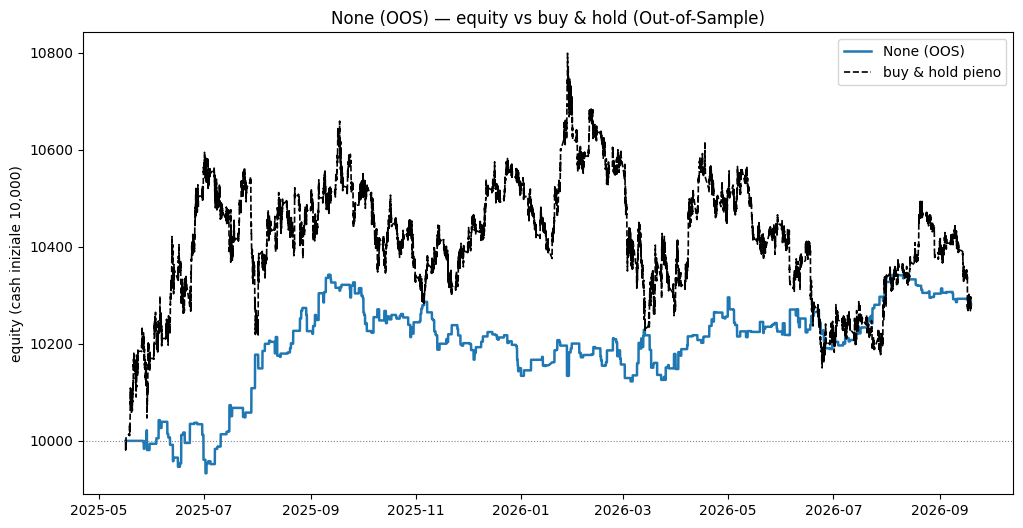

In [ ]:
for nome in [*lista_etichette_filtri_oos, None]:
    ax, curva = plot_equity(oos.trades(nome), df_oos, cash=10_000.0,
                            etichetta=f"{nome} (OOS)")